## RealMLP on Predicting Heart Disease

**Score**
- PB:
- CV:0.95499

**Note**
- Explicitly define the existing RealMLP baseline as "Phase 1: 010_baseline_oof" and save the Out-Of-Fold (OOF) predictions.
- Generate a `noisy_flag` from the OOF predictions, then add experiments in the following order: simple weighting (Phase 2) → p_noise mode (Phase 3) → regime-specific (Phase 4) → rank blend.
- Detect the feasibility of `sample_weight` / `soft-label` using the RealMLP API at runtime; if not feasible, approximate with subsampling.

### Package import

In [13]:
!pip install pytabkit -q

from pathlib import Path
import json
import zipfile
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import warnings
from sklearn.metrics import roc_auc_score
from pytabkit import RealMLP_TD_Classifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# ---- Config ----
COMP_SLUG = "playground-series-s6e2"
KAGGLE_COMP_DIR = Path("/kaggle/input/competitions/playground-series-s6e2")
KAGGLE_EXT_PATH = Path("/kaggle/input/datasets/neurocipher/heartdisease/Heart_Disease_Prediction.csv")

LOCAL_DATA_DIR = Path("data/raw")
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

NEED_FILES = ["train.csv", "test.csv", "sample_submission.csv"]

In [14]:
def run(cmd: list[str]) -> None:
    p = subprocess.run(cmd, capture_output=True, text=True)
    p.check_returncode()


def ensure_kaggle_cli() -> None:
    try:
        pass
    except Exception:
        subprocess.check_call(["pip", "-q", "install", "kaggle"])


def ensure_kaggle_json_interactive_colab(dst: Path = Path("/content/kaggle.json")) -> Path:
    """
    In Colab: open upload dialog if /content/kaggle.json is missing.
    In non-Colab: just require the file to exist.
    """
    if dst.exists():
        print("Found:", dst)
        return dst

    try:
        from google.colab import files  # type: ignore
    except Exception:
        raise FileNotFoundError(
            f"{dst} not found. Please place kaggle.json at {dst} (Colab) "
            "or provide credentials another way."
        )

    print("Upload your kaggle.json (Kaggle -> Account -> API -> Create New Token)")
    uploaded = files.upload()
    cand = None
    if "kaggle.json" in uploaded:
        cand = "kaggle.json"
    else:
        for name in uploaded.keys():
            if name.endswith(".json"):
                cand = name
                break
    if cand is None:
        raise FileNotFoundError("Upload failed: no .json file received.")

    Path(cand).rename(dst)
    print("Saved to:", dst)
    return dst


def install_kaggle_json(src: Path) -> None:
    """
    Copy /content/kaggle.json -> ~/.kaggle/kaggle.json (chmod 600)
    """
    if not src.exists():
        raise FileNotFoundError(f"{src} not found.")

    dst_dir = Path.home() / ".kaggle"
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / "kaggle.json"

    dst.write_bytes(src.read_bytes())
    try:
        dst.chmod(0o600)
    except Exception:
        pass

    cfg = json.loads(dst.read_text())
    if "username" not in cfg or "key" not in cfg:
        raise ValueError("kaggle.json is missing 'username' or 'key'.")
    print(f"Installed kaggle.json for user: {cfg['username']}")


def local_data_ready(data_dir: Path) -> bool:
    return all((data_dir / f).exists() for f in NEED_FILES)


def download_competition_to(data_dir: Path) -> None:
    """
    Download competition zip(s) and extract into data_dir.
    Assumes kaggle CLI + credentials are ready.
    """
    run(["kaggle", "config", "view"])
    run(["kaggle", "competitions", "download", "-c", COMP_SLUG, "-p", str(data_dir), "--force"])

    zips = list(data_dir.glob("*.zip"))
    if not zips:
        raise FileNotFoundError(f"No zip found in {data_dir} after download.")

    for zp in zips:
        with zipfile.ZipFile(zp, "r") as zf:
            zf.extractall(data_dir)
        print("Unzipped:", zp.name)

    if not local_data_ready(data_dir):
        missing = [f for f in NEED_FILES if not (data_dir / f).exists()]
        raise FileNotFoundError(f"Download/unzip finished but missing: {missing}")


In [15]:
if KAGGLE_COMP_DIR.exists():
    DATA_SRC = "kaggle"
    data_dir = KAGGLE_COMP_DIR
    print("Using Kaggle mounted competition data:", data_dir)
else:
    DATA_SRC = "local"
    data_dir = LOCAL_DATA_DIR
    if local_data_ready(data_dir):
        print("Using local data (already present):", data_dir)
    else:
        print("Local data missing -> download using kaggle.json")
        ensure_kaggle_cli()
        kaggle_json_src = ensure_kaggle_json_interactive_colab(Path("/content/kaggle.json"))
        install_kaggle_json(kaggle_json_src)
        download_competition_to(data_dir)
        print("Download complete -> using local data:", data_dir)


# ---- Load ----
train = pd.read_csv(data_dir / "train.csv")
test  = pd.read_csv(data_dir / "test.csv")
sub   = pd.read_csv(data_dir / "sample_submission.csv")

# external dataset: only available if mounted on Kaggle; optional
original = pd.read_csv(KAGGLE_EXT_PATH) if KAGGLE_EXT_PATH.exists() else None

print("train:", train.shape, "test:", test.shape, "sub:", sub.shape, "original:", None if original is None else original.shape)
print("DATA_SRC:", DATA_SRC)

# External data loading
train_comp = train.copy()

# Encode target with LabelEncoder if not numeric
if not pd.api.types.is_numeric_dtype(train_comp["Heart Disease"]):
    le = LabelEncoder()
    train_comp["Heart Disease"] = le.fit_transform(train_comp["Heart Disease"])
    if original is not None and "Heart Disease" in original.columns:
        original["Heart Disease"] = le.transform(original["Heart Disease"])

# Align external columns to train schema
if original is not None:
    if "Heart Disease" not in original.columns:
        raise ValueError("External dataset missing target column: Heart Disease")

    original_aligned = original.copy()
    # add missing columns
    for col in train_comp.columns:
        if col not in original_aligned.columns:
            original_aligned[col] = np.nan

    # ensure id exists
    if "id" not in original_aligned.columns:
        original_aligned["id"] = -(np.arange(len(original_aligned)) + 1)

    # align column order
    original_aligned = original_aligned[train_comp.columns]

    train_full = pd.concat([train_comp, original_aligned], ignore_index=True)
    train_full["is_external"] = [0] * len(train_comp) + [1] * len(original_aligned)
else:
    train_full = train_comp.copy()
    train_full["is_external"] = 0

# use concatenated data for downstream
train = train_full


Using local data (already present): data/raw
train: (630000, 15) test: (270000, 14) sub: (270000, 2) original: None
DATA_SRC: local


In [16]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.set_float32_matmul_precision("high")
N_FOLDS = 5
USE_ALL_CAT = True

print(f"Using device: {DEVICE}")


Using device: cuda


### Data download

In [17]:
display(train.head())
display(test.head())
display(sub.head())

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,is_external
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1,0
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1,0


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [18]:
# Shapes
print("train:", train.shape)
print("test:", test.shape)

# Column diffs
train_cols = set(train.columns)
test_cols = set(test.columns)
print("Only in train:", sorted(train_cols - test_cols))
print("Only in test:", sorted(test_cols - train_cols))

# dtypes
train.dtypes.to_frame("dtype").head(30)


train: (630000, 16)
test: (270000, 14)
Only in train: ['Heart Disease', 'is_external']
Only in test: []


,dtype
id,int64
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64


### Data Preprocessing

In [19]:
def encode_target_strict(y: pd.Series) -> pd.Series:
    """Map common string labels to {0,1}. Raises if unknown."""
    mapping_candidates = [
        {"No": 0, "Yes": 1},
        {"N": 0, "Y": 1},
        {"Negative": 0, "Positive": 1},
        {"Absent": 0, "Present": 1},
        {"Absence": 0, "Presence": 1},
        {0: 0, 1: 1},
        {"0": 0, "1": 1},
    ]
    uniq = set(pd.Series(y).dropna().unique().tolist())
    for mp in mapping_candidates:
        if uniq.issubset(set(mp.keys())):
            return pd.Series(y).map(mp).astype("int8")
    raise ValueError(f"Unknown target labels: {sorted(list(uniq))}")


# ---- target ----
if not pd.api.types.is_numeric_dtype(train["Heart Disease"]):
    train["Heart Disease"] = encode_target_strict(train["Heart Disease"])
if original is not None and "Heart Disease" in original.columns:
    if not pd.api.types.is_numeric_dtype(original["Heart Disease"]):
        original["Heart Disease"] = encode_target_strict(original["Heart Disease"])

TARGET_COL = "Heart Disease"
ID_COL = "id"
META_COLS = [TARGET_COL, ID_COL, "is_external"]

BASE_FEATURES = [c for c in train.columns if c not in META_COLS]

# Canonical S6E2 semantic categoricals (keep as category for embeddings/encoding)
CANONICAL_CAT = {
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium",
}

def split_cols(df: pd.DataFrame):
    base = [c for c in df.columns if c not in META_COLS]
    cat = [c for c in base if c in CANONICAL_CAT]
    num = [c for c in base if c not in cat]
    return cat, num


def add_external_target_stats(df: pd.DataFrame, original_df: pd.DataFrame | None) -> pd.DataFrame:
    """Merge group-wise target stats from the external/original dataset.
    Safe in Playground comps because original_df labels are not the competition labels.
    """
    if original_df is None:
        return df.copy()

    out = df.copy()
    initial_rows = len(out)

    for col in BASE_FEATURES:
        if col not in original_df.columns:
            continue

        stats = (
            original_df.groupby(col)[TARGET_COL]
            .agg(["mean", "median", "std", "skew", "count"])
            .reset_index()
        )
        stats.columns = [col] + [f"orig_{col}_{s}" for s in ["mean", "median", "std", "skew", "count"]]

        out = out.merge(stats, on=col, how="left")
        if len(out) != initial_rows:
            raise ValueError(f"Merge expanded rows for column {col}! {initial_rows} -> {len(out)}")

        # fill NAs for unseen values
        global_mean = float(original_df[TARGET_COL].mean())
        global_median = float(original_df[TARGET_COL].median())
        fill = {
            f"orig_{col}_mean": global_mean,
            f"orig_{col}_median": global_median,
            f"orig_{col}_std": 0.0,
            f"orig_{col}_skew": 0.0,
            f"orig_{col}_count": 0.0,
        }
        out = out.fillna(value=fill)

    return out


def add_frequency_encoding(train_df: pd.DataFrame, test_df: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Add {col}_freq columns using combined train+test frequencies (unsupervised, safe)."""
    tr = train_df.copy()
    te = test_df.copy()

    combined = pd.concat([tr[cols], te[cols]], axis=0, ignore_index=True)
    for col in cols:
        freq = combined[col].value_counts(dropna=False)
        tr[f"{col}_freq"] = tr[col].map(freq).astype("float32")
        te[f"{col}_freq"] = te[col].map(freq).astype("float32")
    return tr, te


def compute_periodic_t_map(train_df: pd.DataFrame, cols: list[str]) -> dict[str, float]:
    t_map: dict[str, float] = {}
    for col in cols:
        series = pd.to_numeric(train_df[col], errors="coerce")
        t = float(series.max() - series.min())
        if not np.isfinite(t) or t <= 0:
            t = 1.0
        t_map[col] = t
    return t_map


def add_periodic_encoding(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    cols: list[str],
    t_map: dict[str, float],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    tr = train_df.copy()
    te = test_df.copy()

    for col in cols:
        t = t_map.get(col, 1.0)
        tr_col = pd.to_numeric(tr[col], errors="coerce").astype("float32")
        te_col = pd.to_numeric(te[col], errors="coerce").astype("float32")
        tr[f"{col}_sin"] = np.sin(2 * np.pi * tr_col / t).astype("float32")
        tr[f"{col}_cos"] = np.cos(2 * np.pi * tr_col / t).astype("float32")
        te[f"{col}_sin"] = np.sin(2 * np.pi * te_col / t).astype("float32")
        te[f"{col}_cos"] = np.cos(2 * np.pi * te_col / t).astype("float32")

    return tr, te


def build_features(
    train_fe: pd.DataFrame,
    test_fe: pd.DataFrame,
    cat_cols: list[str],
    num_cols: list[str],
):
    tr = train_fe.copy()
    te = test_fe.copy()

    base_numeric = [c for c in num_cols if not c.startswith("orig_")]

    t_map = compute_periodic_t_map(tr, base_numeric)
    tr, te = add_periodic_encoding(tr, te, base_numeric, t_map)

    print(f"Train Shape after FE: {tr.shape}")
    print(f"Test Shape after FE:  {te.shape}")

    # ---- Build X/y with clean dtypes ----
    drop_tr = [c for c in META_COLS if c in tr.columns]
    drop_te = [c for c in [ID_COL] if c in te.columns]

    X = tr.drop(columns=drop_tr).copy()
    X_test = te.drop(columns=drop_te).copy()
    y = tr[TARGET_COL].copy()

    cat_cols_final = [c for c in X.columns if c in cat_cols]
    num_cols_final = [c for c in X.columns if c not in cat_cols_final]

    # Ensure no overlap
    assert set(cat_cols_final).isdisjoint(set(num_cols_final))

    for c in cat_cols_final:
        combined = pd.concat([X[c], X_test[c]], axis=0, ignore_index=True)
        cats = pd.Categorical(combined).categories
        X[c] = pd.Categorical(X[c], categories=cats)
        X_test[c] = pd.Categorical(X_test[c], categories=cats)

    for c in num_cols_final:
        X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")
        X_test[c] = pd.to_numeric(X_test[c], errors="coerce").astype("float32")

    return X, X_test, y, cat_cols_final, num_cols_final


# ---- Feature engineering (per EDA) ----
train_fe = add_external_target_stats(train, original)
test_fe  = add_external_target_stats(test, original)

cat_cols, num_cols = split_cols(train_fe)
BASE_NUMERIC_COLS = [c for c in num_cols if not c.startswith("orig_")]

# Frequency encoding for semantic categoricals
train_fe, test_fe = add_frequency_encoding(train_fe, test_fe, cat_cols)

print("=== Building features: periodic_only ===")
X_tmp, X_test_tmp, y_tmp, cat_cols_final, num_cols_final = build_features(
    train_fe, test_fe, cat_cols, num_cols
)

assert any(c.endswith("_sin") for c in X_tmp.columns)
assert any(c.endswith("_cos") for c in X_tmp.columns)
assert all(str(X_tmp[c].dtype) == "category" for c in cat_cols_final)
assert all(X_tmp[c].dtype == "float32" for c in num_cols_final)

print("Categorical cols:", len(cat_cols_final))
print("Numeric cols:", len(num_cols_final))

features = {
    "periodic_only": {
        "X": X_tmp,
        "X_test": X_test_tmp,
        "y": y_tmp,
        "cat_cols": cat_cols_final,
        "num_cols": num_cols_final,
    }
}

PRIMARY_CONFIG = "periodic_only"
X = features[PRIMARY_CONFIG]["X"]
X_test = features[PRIMARY_CONFIG]["X_test"]
y = features[PRIMARY_CONFIG]["y"]
cat_cols = features[PRIMARY_CONFIG]["cat_cols"]

print(f"PRIMARY_CONFIG={PRIMARY_CONFIG}")
print(f"X: {X.shape}, X_test: {X_test.shape}, y: {y.shape}")


=== Building features: periodic_only ===
Train Shape after FE: (630000, 34)
Test Shape after FE:  (270000, 32)
Categorical cols: 8
Numeric cols: 23
PRIMARY_CONFIG=periodic_only
X: (630000, 31), X_test: (270000, 31), y: (630000,)


### Data Quality Check

In [20]:
def check_data_quality(df, name="Dataset"):
    print(f"--- Data Quality: {name} ---")
    print(f"Total Rows: {len(df)}")

    cols_to_check = [c for c in df.columns if c != 'id']
    dupes = df.duplicated(subset=cols_to_check).sum()

    nan_counts = df.isnull().sum()
    total_nans = nan_counts.sum()

    print(f"Duplicate Rows (excl. ID): {dupes}")
    print(f"Total NaN values: {total_nans}")
    if total_nans > 0:
        print("\nColumns with NaNs:")
        print(nan_counts[nan_counts > 0])
    print("-" * 30)

check_data_quality(train, "Train")
check_data_quality(test, "Test")

--- Data Quality: Train ---
Total Rows: 630000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------
--- Data Quality: Test ---
Total Rows: 270000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------


### Feature Uniqueness & Cardinality

In [21]:
# Target distribution analysis

def analyze_uniqueness(df):
    unique_stats = []
    for col in df.columns:
        if col == 'id':
            continue

        n_unique = df[col].nunique()
        dtype = df[col].dtype

        category_guess = "Categorical/Ordinal" if n_unique < 25 else "Continuous"

        if pd.api.types.is_numeric_dtype(df[col]):
            mean_val = float(pd.to_numeric(df[col], errors='coerce').mean())
            std_val = float(pd.to_numeric(df[col], errors='coerce').std())
        else:
            mean_val = float('nan')
            std_val = float('nan')

        unique_stats.append({
            'Feature': col,
            'Unique Values': n_unique,
            'Data Type': dtype,
            'Heuristic Type': category_guess,
            'Mean': mean_val,
            'Std': std_val,
        })

    return pd.DataFrame(unique_stats).sort_values(by='Unique Values')

# class imbalance
comp_mask = (train["is_external"] == 0)
ext_mask  = (train["is_external"] == 1)

print("=== Target distribution: COMP ONLY ===")
print(train.loc[comp_mask, TARGET_COL].value_counts(dropna=False))
print(train.loc[comp_mask, TARGET_COL].value_counts(normalize=True, dropna=False))

print("\n=== Target distribution: EXTERNAL ONLY ===")
print(train.loc[ext_mask, TARGET_COL].value_counts(dropna=False))
print(train.loc[ext_mask, TARGET_COL].value_counts(normalize=True, dropna=False))

print("\n=== Target distribution: MERGED (comp + external) ===")
print(train[TARGET_COL].value_counts(dropna=False))
print(train[TARGET_COL].value_counts(normalize=True, dropna=False))

uniqueness_df = analyze_uniqueness(train)
uniqueness_df


=== Target distribution: COMP ONLY ===
Heart Disease
0    347546
1    282454
Name: count, dtype: int64
Heart Disease
0    0.55166
1    0.44834
Name: proportion, dtype: float64

=== Target distribution: EXTERNAL ONLY ===
Series([], Name: count, dtype: int64)
Series([], Name: proportion, dtype: float64)

=== Target distribution: MERGED (comp + external) ===
Heart Disease
0    347546
1    282454
Name: count, dtype: int64
Heart Disease
0    0.55166
1    0.44834
Name: proportion, dtype: float64


,Feature,Unique Values,Data Type,Heuristic Type,Mean,Std
14,is_external,1,int64,Categorical/Ordinal,0.000000,0.000000
1,Sex,2,int64,Categorical/Ordinal,0.714735,0.451541
8,Exercise angina,2,int64,Categorical/Ordinal,0.273725,0.445870
5,FBS over 120,2,int64,Categorical/Ordinal,0.079987,0.271274
13,Heart Disease,2,int64,Categorical/Ordinal,0.448340,0.497324
10,Slope of ST,3,int64,Categorical/Ordinal,1.455871,0.545192
6,EKG results,3,int64,Categorical/Ordinal,0.981660,0.998783
12,Thallium,3,int64,Categorical/Ordinal,4.618873,1.950007
2,Chest pain type,4,int64,Categorical/Ordinal,3.312752,0.851615
11,Number of vessels fluro,4,int64,Categorical/Ordinal,0.451040,0.798549


### Visualize Top Skewed Features

Top 6 Most Skewed Features (Absolute Values):
EKG results_freq    -16.972622
FBS over 120_freq    -3.096606
Cholesterol_cos       2.016195
Slope of ST_freq     -1.947209
BP_sin               -1.799833
Max HR_sin           -1.626266
dtype: float32


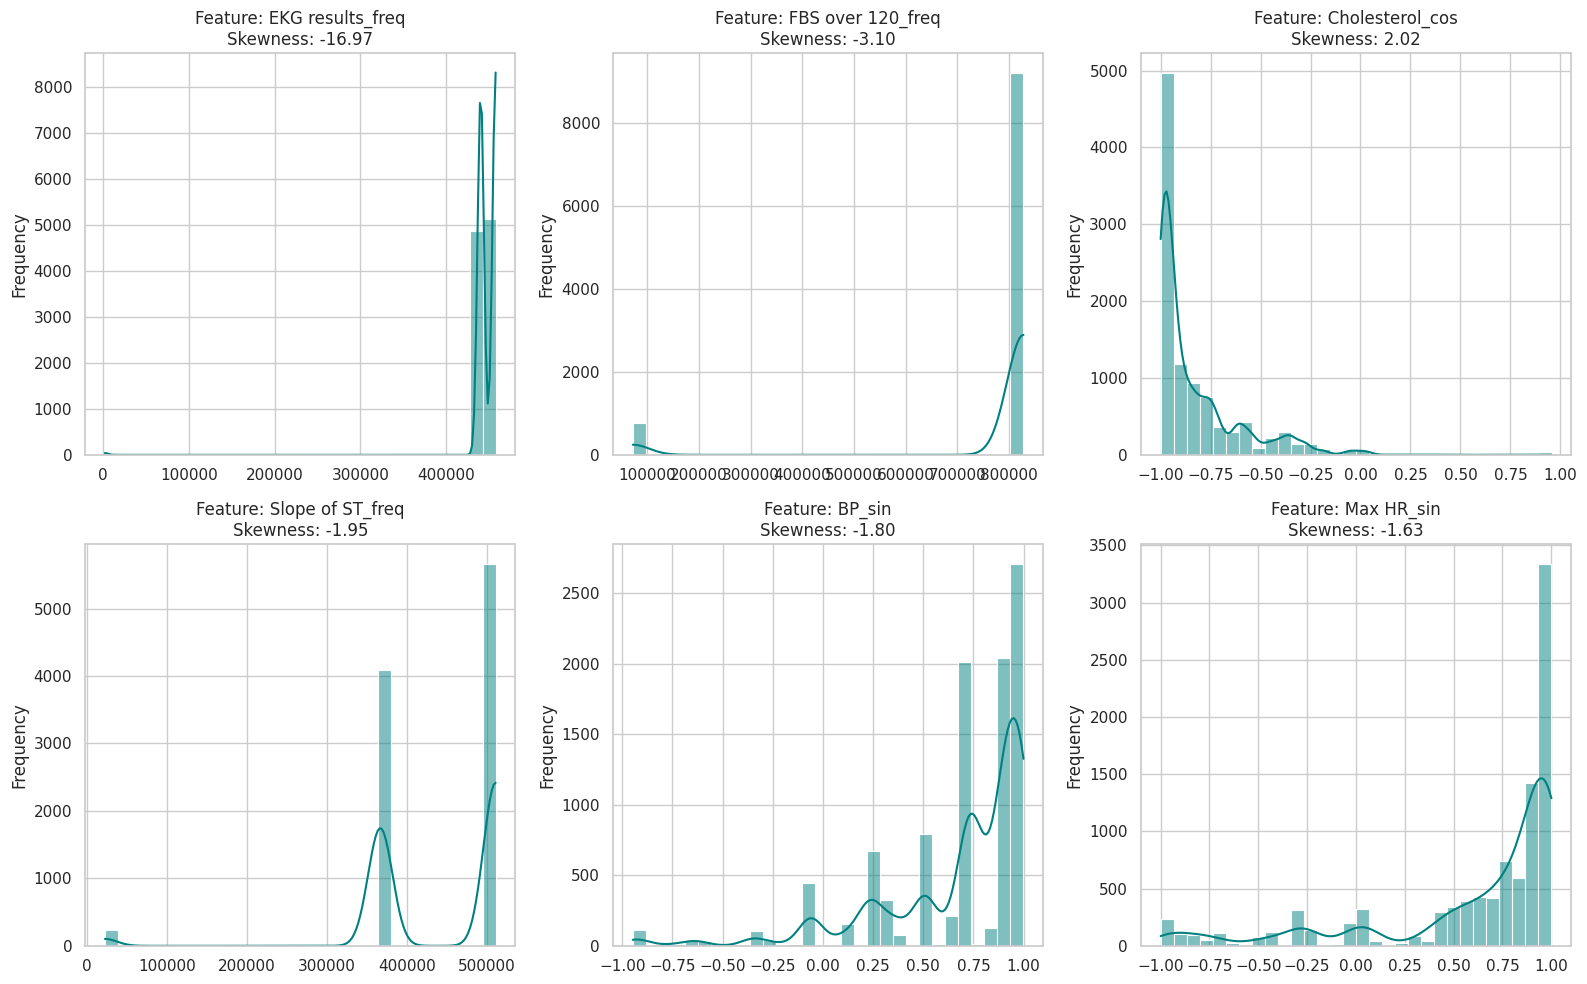

In [22]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

skew_series = X[numeric_cols].skew().abs().sort_values(ascending=False)
top_skewed_features = skew_series.head(6).index.tolist()

print("Top 6 Most Skewed Features (Absolute Values):")
print(X[top_skewed_features].skew())

plt.figure(figsize=(16, 10))
for i, col in enumerate(top_skewed_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(X[col].sample(min(10000, len(X))), kde=True, color='teal', bins=30)
    plt.title(f"Feature: {col}\nSkewness: {X[col].skew():.2f}")
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Label Flipping Experiments (Phases 1-4)

### Setup & Utilities


In [ ]:
from pathlib import Path
import inspect

OUTPUT_DIR = Path("nb_outputs/035_label_flipping")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def make_folds(X, y, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return list(skf.split(X, y))

def save_oof(pred, y_true, ids, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame({
        "id": ids,
        "y_true": y_true,
        "y_pred": pred,
    })
    df.to_csv(path, index=False)
    print(f"[save] OOF -> {path}  (rows={len(df):,})")

def summarize_cv(fold_scores):
    return {
        "mean": float(np.mean(fold_scores)),
        "std": float(np.std(fold_scores)),
    }

def rank01(pred):
    s = pd.Series(pred)
    return s.rank(method="average", pct=True).values

def _detect_realmlp_support():
    supports_sample_weight = "sample_weight" in inspect.signature(RealMLP_TD_Classifier.fit).parameters
    regressor_cls = None
    supports_soft_labels = False
    try:
        from pytabkit import RealMLP_TD_Regressor
        regressor_cls = RealMLP_TD_Regressor
        supports_soft_labels = True
    except Exception:
        supports_soft_labels = False
    return supports_sample_weight, supports_soft_labels, regressor_cls

supports_sample_weight, supports_soft_labels, RealMLP_TD_Regressor_cls = _detect_realmlp_support()
print(f"supports_sample_weight={supports_sample_weight}, supports_soft_labels={supports_soft_labels}")


In [ ]:
def _predict_prob(model, X):
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)
        if prob.ndim == 2 and prob.shape[1] > 1:
            return prob[:, 1]
        return prob.reshape(-1)
    pred = model.predict(X)
    pred = np.asarray(pred).reshape(-1)
    return np.clip(pred, 0.0, 1.0)

def run_realmlp_cv(
    X, y, X_test, folds, params,
    sample_weight=None, y_train_override=None,
    tag="", model_class=None, min_keep=0.05, seed=42
):
    oof_preds = np.zeros(len(X), dtype=np.float32)
    test_preds = np.zeros(len(X_test), dtype=np.float32)
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(folds, start=1):
        X_tr = X.iloc[train_idx]
        y_tr = y.iloc[train_idx]
        if y_train_override is not None:
            y_tr = np.asarray(y_train_override)[train_idx]
        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        if sample_weight is not None and not supports_sample_weight:
            w_tr = np.asarray(sample_weight)[train_idx]
            keep_prob = np.clip(w_tr, min_keep, 1.0)
            rng = np.random.RandomState(seed + fold)
            keep_mask = rng.rand(len(train_idx)) < keep_prob
            if keep_mask.sum() < 10:
                keep_mask = np.ones(len(train_idx), dtype=bool)
            X_tr = X_tr.iloc[keep_mask]
            y_tr = np.asarray(y_tr)[keep_mask]

        model_cls = model_class or RealMLP_TD_Classifier
        model = model_cls(**params)

        if sample_weight is not None and supports_sample_weight:
            w_tr = np.asarray(sample_weight)[train_idx]
            try:
                model.fit(X_tr, np.asarray(y_tr), X_val, y_val.values, sample_weight=w_tr)
            except TypeError:
                model.fit(X_tr, np.asarray(y_tr), X_val, y_val.values)
        else:
            model.fit(X_tr, np.asarray(y_tr), X_val, y_val.values)

        val_probs = _predict_prob(model, X_val)
        test_probs = _predict_prob(model, X_test)

        oof_preds[val_idx] = val_probs
        test_preds += test_probs / len(folds)

        score = roc_auc_score(y_val, val_probs)
        fold_scores.append(float(score))
        print(f"[{tag}] fold {fold} AUC={score:.6f}")

        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    return oof_preds, test_preds, fold_scores


### Cross-Validation & Training

In [34]:
%%time

# =========================
# Fixed params (Best from HPO)
# =========================
N_FOLDS = 5
RANDOM_STATE = 42
PRIMARY_CONFIG = "periodic_only"

params = {
    "device": DEVICE,              # "cuda" or "cpu"
    'random_state': 42,
    'verbosity': 2,
    'n_epochs': 100,
    'batch_size': 2**12,
    'n_ens': 2,
    'use_early_stopping': True,
    'early_stopping_additive_patience': 20,
    'early_stopping_multiplicative_patience': 1,
    'act': "mish",
    'embedding_size': 8,
    'first_layer_lr_factor': 0.5962121993798933,
    'hidden_sizes': "rectangular",
    'hidden_width': 384,
    'lr': 0.04,
    'ls_eps': 0.011498317194338772,
    'ls_eps_sched': "coslog4",
    'max_one_hot_cat_size': 18,
    'n_hidden_layers': 4,
    'p_drop': 0.07301419697186451,
    'p_drop_sched': "flat_cos",
    'plr_hidden_1': 16,
    'plr_hidden_2': 8,
    'plr_lr_factor': 0.1151437622270563,
    'plr_sigma': 2.3316811282666916,
    'scale_lr_factor': 2.244801835541429,
    'sq_mom': 1.0 - 0.011834054955582318,
    'wd': 0.02369230879235962,
}

print("Using fixed params (submission-style):")
display(pd.Series(params))


Using fixed params (submission-style):


,0
device,cuda
random_state,42
verbosity,2
n_epochs,100
batch_size,4096
n_ens,2
use_early_stopping,True
early_stopping_additive_patience,20
early_stopping_multiplicative_patience,1
act,mish


CPU times: user 7.45 ms, sys: 0 ns, total: 7.45 ms
Wall time: 27.7 ms


In [35]:
import time
from datetime import datetime
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

feat = features[PRIMARY_CONFIG]
X = feat["X"].copy()
X_test = feat["X_test"].copy()
y = feat["y"].copy()

# OOF prediction (dtypes already set in build_features)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(X), dtype=np.float32)
test_preds = np.zeros(len(X_test), dtype=np.float32)
fold_scores = []

t_total_start = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    t_fold_start = time.time()

    # ── フォールド開始ログ ──────────────────────────────
    print(f"\n{'='*55}")
    print(f"  Fold {fold}/{N_FOLDS}  |  started at {datetime.now().strftime('%H:%M:%S')}")
    print(f"{'='*55}")

    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]

    # SUB_FRAC = 0.3
    # sss = StratifiedShuffleSplit(
    #     n_splits=1,
    #     train_size=int(len(X_tr) * SUB_FRAC),
    #     random_state=RANDOM_STATE + fold
    # )
    # sub_idx, _ = next(sss.split(X_tr, y_tr))
    # X_tr = X_tr.iloc[sub_idx]
    # y_tr = y_tr.iloc[sub_idx]

    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    print(f"  [data]  train={len(X_tr):,}  val={len(X_val):,}  "
          f"pos_rate(tr)={y_tr.mean():.3f}  pos_rate(val)={y_val.mean():.3f}")

    # ── モデル学習 ──────────────────────────────────────
    print(f"  [fit]   starting RealMLP_TD training ...")
    t_fit = time.time()
    model = RealMLP_TD_Classifier(**params)
    model.fit(X_tr, y_tr.values, X_val, y_val.values)
    print(f"  [fit]   done in {time.time()-t_fit:.1f}s")

    # ── 予測 ────────────────────────────────────────────
    print(f"  [pred]  predicting val & test ...")
    val_probs  = model.predict_proba(X_val)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    oof_preds[val_idx] = val_probs
    test_preds += test_probs / N_FOLDS

    # ── フォールドスコア ─────────────────────────────────
    score = roc_auc_score(y_val, val_probs)
    fold_scores.append(score)
    elapsed = time.time() - t_fold_start
    total_elapsed = time.time() - t_total_start

    eta = (total_elapsed / fold) * (N_FOLDS - fold)  # 残り時間推定

    print(f"\n  Fold {fold} AUC : {score:.5f}")
    print(f"  Scores so far : {[round(s,5) for s in fold_scores]}")
    print(f"  Running mean  : {np.mean(fold_scores):.5f}  ±  {np.std(fold_scores):.5f}")
    print(f"  Fold time     : {elapsed:.1f}s  |  Total: {total_elapsed:.1f}s  |  ETA: {eta:.1f}s")

    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        print("  [cuda]  cache cleared")

# ── 最終サマリー ──────────────────────────────────────
total_time = time.time() - t_total_start
mean_auc = float(np.mean(fold_scores))
std_auc  = float(np.std(fold_scores))
oof_auc  = float(roc_auc_score(y, oof_preds))

print(f"\n{'#'*55}")
print(f"  CV SUMMARY")
print(f"{'#'*55}")
print(f"  Fold scores : {[round(s,6) for s in fold_scores]}")
print(f"  Mean AUC    : {mean_auc:.6f}")
print(f"  Std AUC     : {std_auc:.6f}")
print(f"  OOF AUC     : {oof_auc:.6f}")
print(f"  Total time  : {total_time:.1f}s  ({total_time/60:.1f}min)")
print(f"{'#'*55}")


  Fold 1/5  |  started at 09:19:06
  [data]  train=504,000  val=126,000  pos_rate(tr)=0.448  pos_rate(val)=0.448
  [fit]   starting RealMLP_TD training ...
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq', 'Age_sin', 'Age_cos', 'BP_sin', 'BP_cos', 'Cholesterol_sin', 'Cholesterol_cos', 'Max HR_sin', 'Max HR_cos', 'ST depression_sin', 'ST depression_cos']
Columns classified as categorical: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/100: val class_error = 0.112627
Epoch 2/100: val class_error = 0.112175
Epoch 3/100: val class_error = 0.112246
Epoch 4/100: val class_error = 0.111460
Epoch 5/100: val class_error = 0.111032
Epoch 6/100: val class_error = 0.110524
Epoch 7/100: val class_error = 0.110341
Epoch 8/100: val class_error = 0.110929
Epoch 9/100: val class_error = 0.110619
Epoch 10/100: val class_error = 0.111802
Epoch 11/100: val class_error = 0.110548
Epoch 12/100: val class_error = 0.111175
Epoch 13/100: val class_error = 0.110516
Epoch 14/100: val class_error = 0.110278
Epoch 15/100: val class_error = 0.109976
Epoch 16/100: val class_error = 0.110000
Epoch 17/100: val class_error = 0.110317
Epoch 18/100: val class_error = 0.110159
Epoch 19/100: val class_error = 0.110246
Epoch 20/100: val class_error = 0.110325
Epoch 21/100: val class_error = 0.110317
Epoch 22/100: val class_error = 0.110183
Epoch 23/100: val class_error = 0.110421
Epoch 24/100: val class_error = 0.110484
Epoch 25/100: val class_e

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  [fit]   done in 121.8s
  [pred]  predicting val & test ...


...

Epoch 1/100: val class_error = 0.113849
Epoch 2/100: val class_error = 0.112421
Epoch 3/100: val class_error = 0.112119
Epoch 4/100: val class_error = 0.112429
Epoch 5/100: val class_error = 0.112048
Epoch 6/100: val class_error = 0.111873
Epoch 7/100: val class_error = 0.111873
Epoch 8/100: val class_error = 0.111921
Epoch 9/100: val class_error = 0.112040
Epoch 10/100: val class_error = 0.111548
Epoch 11/100: val class_error = 0.111619
Epoch 12/100: val class_error = 0.111333
Epoch 13/100: val class_error = 0.111571
Epoch 14/100: val class_error = 0.111230
Epoch 15/100: val class_error = 0.111563
Epoch 16/100: val class_error = 0.111500
Epoch 17/100: val class_error = 0.111357
Epoch 18/100: val class_error = 0.111571
Epoch 19/100: val class_error = 0.111516
Epoch 20/100: val class_error = 0.111659
Epoch 21/100: val class_error = 0.111516
Epoch 22/100: val class_error = 0.111794
Epoch 23/100: val class_error = 0.111381
Epoch 24/100: val class_error = 0.111786
Epoch 25/100: val class_e

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  [fit]   done in 117.0s
  [pred]  predicting val & test ...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  Fold 5 AUC : 0.95550
  Scores so far : [np.float64(0.95551), np.float64(0.95451), np.float64(0.95512), np.float64(0.95474), np.float64(0.9555)]
  Running mean  : 0.95508  ±  0.00040
  Fold time     : 118.6s  |  Total: 609.4s  |  ETA: 0.0s
  [cuda]  cache cleared

#######################################################
  CV SUMMARY
#######################################################
  Fold scores : [np.float64(0.955514), np.float64(0.954505), np.float64(0.955121), np.float64(0.954738), np.float64(0.955503)]
  Mean AUC    : 0.955076
  Std AUC     : 0.000404
  OOF AUC     : 0.954993
  Total time  : 609.4s  (10.2min)
#######################################################


### Phase 1: 010_baseline_oof (save OOF)


In [ ]:
folds = make_folds(X, y, n_splits=N_FOLDS, seed=RANDOM_STATE)
BASELINE_DIR = OUTPUT_DIR / "010_baseline_oof"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

comp_len = len(train_comp)
comp_ids = train_comp["id"].values

save_oof(oof_preds[:comp_len], y.iloc[:comp_len].values, comp_ids, BASELINE_DIR / "oof_pred.csv")
np.save(BASELINE_DIR / "test_pred.npy", test_preds)
print(f"[save] test_pred -> {BASELINE_DIR / 'test_pred.npy'}")


### Phase 2: noisy_flag extraction & weighted training


In [ ]:
NOISE_THRESHOLDS = [(0.10, 0.90), (0.05, 0.95), (0.15, 0.85)]
DEFAULT_T_LOW, DEFAULT_T_HIGH = NOISE_THRESHOLDS[0]

def make_noisy_flag(y_true, y_pred, t_low, t_high):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    noisy = np.zeros_like(y_true, dtype=int)
    noisy[(y_true == 1) & (y_pred < t_low)] = 1
    noisy[(y_true == 0) & (y_pred > t_high)] = 1
    return noisy

noisy_flags = {}
for t_low, t_high in NOISE_THRESHOLDS:
    nf = make_noisy_flag(y.values, oof_preds, t_low, t_high)
    noisy_flags[(t_low, t_high)] = nf
    print(f"thresholds=({t_low:.2f},{t_high:.2f}) noisy_rate={nf.mean():.4f}")

# Quick feature distribution check
preferred_cols = ["ST depression", "Number of vessels fluro", "Thallium"]
available = [c for c in preferred_cols if c in train_comp.columns]
if len(available) < 3:
    numeric_cols = [c for c in BASE_FEATURES if c in train_comp.columns and pd.api.types.is_numeric_dtype(train_comp[c])]
    available = (available + numeric_cols)[:3]

noisy_default = noisy_flags[(DEFAULT_T_LOW, DEFAULT_T_HIGH)]
if available:
    display(train_comp[available].assign(noisy_flag=noisy_default).groupby("noisy_flag").describe())
else:
    print("[warn] No numeric columns found for distribution summary")

# Phase 2-2: weighted training
ALPHAS = [0.3, 0.5, 0.7]
weighted_noise_results = []

for alpha in ALPHAS:
    w = 1.0 - alpha * noisy_default
    tag = f"021_weighted_noise_alpha_{alpha}"
    print(f"
== {tag} ==")
    oof_w, test_w, scores_w = run_realmlp_cv(X, y, X_test, folds, params, sample_weight=w, tag=tag, seed=RANDOM_STATE)
    stats = summarize_cv(scores_w)
    print(f"[{tag}] mean={stats['mean']:.6f} std={stats['std']:.6f} oof={roc_auc_score(y, oof_w):.6f}")
    out_dir = OUTPUT_DIR / "021_weighted_noise" / f"alpha_{alpha}"
    save_oof(oof_w[:comp_len], y.iloc[:comp_len].values, comp_ids, out_dir / "oof_pred.csv")
    np.save(out_dir / "test_pred.npy", test_w)
    weighted_noise_results.append({"alpha": alpha, "oof": float(roc_auc_score(y, oof_w)), "oof_pred": oof_w, "test_pred": test_w})


### Phase 3: p_noise model & usage


In [ ]:
NOISE_MODEL_PARAMS = params.copy()

# 3-1: train noisy_flag model
tag_noise = "030_noise_model_realmlp"
y_noise = noisy_default
print(f"
== {tag_noise} ==")
p_noise_oof, p_noise_test, p_noise_scores = run_realmlp_cv(X, pd.Series(y_noise), X_test, folds, NOISE_MODEL_PARAMS, tag=tag_noise, seed=RANDOM_STATE)
print(f"[{tag_noise}] mean={np.mean(p_noise_scores):.6f} oof_auc={roc_auc_score(y_noise, p_noise_oof):.6f}")
out_dir = OUTPUT_DIR / "030_noise_model_realmlp"
save_oof(p_noise_oof[:comp_len], y_noise[:comp_len], comp_ids, out_dir / "p_noise_oof.csv")
np.save(out_dir / "p_noise_oof.npy", p_noise_oof)

# 3-2: weighted by p_noise
LAMBDAS = [0.3, 0.5, 0.7]
weighted_pnoise_results = []

for lam in LAMBDAS:
    w = 1.0 - lam * p_noise_oof
    tag = f"031_weighted_pnoise_lambda_{lam}"
    print(f"
== {tag} ==")
    oof_w, test_w, scores_w = run_realmlp_cv(X, y, X_test, folds, params, sample_weight=w, tag=tag, seed=RANDOM_STATE)
    stats = summarize_cv(scores_w)
    print(f"[{tag}] mean={stats['mean']:.6f} std={stats['std']:.6f} oof={roc_auc_score(y, oof_w):.6f}")
    out_dir = OUTPUT_DIR / "031_weighted_pnoise" / f"lambda_{lam}"
    save_oof(oof_w[:comp_len], y.iloc[:comp_len].values, comp_ids, out_dir / "oof_pred.csv")
    np.save(out_dir / "test_pred.npy", test_w)
    weighted_pnoise_results.append({"lambda": lam, "oof": float(roc_auc_score(y, oof_w)), "oof_pred": oof_w, "test_pred": test_w})

# 3-2: soft-labels
tag_soft = "032_softlabel_pnoise"
y_eff = (1.0 - p_noise_oof) * y.values + p_noise_oof * (1.0 - y.values)

softlabel_ok = False
soft_oof = None
soft_test = None
try:
    if RealMLP_TD_Regressor_cls is not None:
        print(f"
== {tag_soft} (regressor) ==")
        soft_oof, soft_test, soft_scores = run_realmlp_cv(
            X, y, X_test, folds, params, y_train_override=y_eff,
            tag=tag_soft, model_class=RealMLP_TD_Regressor_cls, seed=RANDOM_STATE
        )
        softlabel_ok = True
    else:
        print(f"
== {tag_soft} (classifier attempt) ==")
        soft_oof, soft_test, soft_scores = run_realmlp_cv(
            X, y, X_test, folds, params, y_train_override=y_eff,
            tag=tag_soft, seed=RANDOM_STATE
        )
        softlabel_ok = True
except Exception as e:
    print(f"[skip] soft-label training failed: {e}")
    softlabel_ok = False

if softlabel_ok:
    out_dir = OUTPUT_DIR / "032_softlabel_pnoise"
    save_oof(soft_oof[:comp_len], y.iloc[:comp_len].values, comp_ids, out_dir / "oof_pred.csv")
    np.save(out_dir / "test_pred.npy", soft_test)


### Phase 4: Regime modeling & rank blending


In [ ]:
def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def assign_regime(train_df, test_df):
    st_col = _find_col(train_df, ["ST depression", "oldpeak", "ST"])
    ca_col = _find_col(train_df, ["Number of vessels fluro", "CA", "ca"])
    th_col = _find_col(train_df, ["Thallium", "Thal", "thal"])

    def _regime(df):
        st = pd.to_numeric(df[st_col], errors="coerce") if st_col else pd.Series(0, index=df.index)
        ca = pd.to_numeric(df[ca_col], errors="coerce") if ca_col else pd.Series(0, index=df.index)
        th = df[th_col] if th_col else pd.Series("unknown", index=df.index)
        th_mode = th.mode().iloc[0] if th_col else "unknown"

        reg = pd.Series("regime4", index=df.index)
        reg[(st == 0) & (ca == 0)] = "regime1"
        reg[(st == 0) & (ca == 0) & (th != th_mode)] = "regime2"
        reg[(st > 0) | (ca > 0)] = "regime3"
        return reg

    return _regime(train_df), _regime(test_df)

regime_train, regime_test = assign_regime(train_comp, test)
regime_all = pd.Categorical(pd.concat([regime_train, regime_test], axis=0))
regime_train = pd.Categorical(regime_train, categories=regime_all.categories)
regime_test = pd.Categorical(regime_test, categories=regime_all.categories)

X_regime = X.copy()
X_test_regime = X_test.copy()
X_regime["regime"] = regime_train
X_test_regime["regime"] = regime_test

print("Regime counts (train):")
display(pd.Series(regime_train).value_counts())

# 4-2: regime feature model
tag_reg_feat = "042_regime_feature"
oof_reg_feat, test_reg_feat, scores_reg_feat = run_realmlp_cv(
    X_regime, y, X_test_regime, folds, params, tag=tag_reg_feat, seed=RANDOM_STATE
)
print(f"[{tag_reg_feat}] mean={np.mean(scores_reg_feat):.6f} oof={roc_auc_score(y, oof_reg_feat):.6f}")
out_dir = OUTPUT_DIR / "042_regime_feature"
save_oof(oof_reg_feat[:comp_len], y.iloc[:comp_len].values, comp_ids, out_dir / "oof_pred.csv")
np.save(out_dir / "test_pred.npy", test_reg_feat)

# 4-2: regime-specific model
def run_realmlp_cv_regime_specific(X, y, X_test, folds, params, regime_train, regime_test, min_samples=1000):
    oof = np.zeros(len(X), dtype=np.float32)
    test_pred = np.zeros(len(X_test), dtype=np.float32)
    regs = pd.Series(regime_train).astype(str)
    regs_test = pd.Series(regime_test).astype(str)

    for fold, (tr_idx, va_idx) in enumerate(folds, start=1):
        # global model for fallback
        global_model = RealMLP_TD_Classifier(**params)
        global_model.fit(X.iloc[tr_idx], y.iloc[tr_idx].values, X.iloc[va_idx], y.iloc[va_idx].values)
        val_global = _predict_prob(global_model, X.iloc[va_idx])
        test_global = _predict_prob(global_model, X_test)

        val_pred = val_global.copy()
        test_fold = test_global.copy()

        for r in sorted(regs.unique()):
            tr_mask = (regs.iloc[tr_idx].values == r)
            va_mask = (regs.iloc[va_idx].values == r)
            if va_mask.sum() == 0:
                continue
            if tr_mask.sum() < min_samples:
                continue
            model_r = RealMLP_TD_Classifier(**params)
            model_r.fit(X.iloc[tr_idx][tr_mask], y.iloc[tr_idx].values[tr_mask], X.iloc[va_idx][va_mask], y.iloc[va_idx].values[va_mask])
            val_pred[va_mask] = _predict_prob(model_r, X.iloc[va_idx][va_mask])
            test_mask = (regs_test.values == r)
            if test_mask.sum() > 0:
                test_fold[test_mask] = _predict_prob(model_r, X_test[test_mask])

        oof[va_idx] = val_pred
        test_pred += test_fold / len(folds)
        score = roc_auc_score(y.iloc[va_idx], val_pred)
        print(f"[042_regime_specific] fold {fold} AUC={score:.6f}")
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    return oof, test_pred

oof_reg_spec, test_reg_spec = run_realmlp_cv_regime_specific(
    X_regime, y, X_test_regime, folds, params, regime_train, regime_test, min_samples=1000
)
print(f"[042_regime_specific] oof={roc_auc_score(y, oof_reg_spec):.6f}")
out_dir = OUTPUT_DIR / "042_regime_specific"
save_oof(oof_reg_spec[:comp_len], y.iloc[:comp_len].values, comp_ids, out_dir / "oof_pred.csv")
np.save(out_dir / "test_pred.npy", test_reg_spec)

# 4-3: rank blend
def _best_result(results, key):
    if not results:
        return None
    return sorted(results, key=lambda x: x[key], reverse=True)[0]

best_w_noise = _best_result(weighted_pnoise_results, "oof")
best_regime_oof = oof_reg_feat
best_regime_test = test_reg_feat
if roc_auc_score(y, oof_reg_spec) > roc_auc_score(y, oof_reg_feat):
    best_regime_oof = oof_reg_spec
    best_regime_test = test_reg_spec

blend_candidates = {
    "M1_baseline": oof_preds,
    "M2_weighted_pnoise": best_w_noise["oof_pred"] if best_w_noise else oof_preds,
    "M3_regime": best_regime_oof,
}
blend_test = {
    "M1_baseline": test_preds,
    "M2_weighted_pnoise": best_w_noise["test_pred"] if best_w_noise else test_preds,
    "M3_regime": best_regime_test,
}

weights_grid = [0.2, 0.3, 0.5]
best_auc = -1
best_weights = None
best_blend_oof = None
for w1 in weights_grid:
    for w2 in weights_grid:
        for w3 in weights_grid:
            blend = (w1 * rank01(blend_candidates["M1_baseline"]) +
                     w2 * rank01(blend_candidates["M2_weighted_pnoise"]) +
                     w3 * rank01(blend_candidates["M3_regime"]))
            auc = roc_auc_score(y, blend)
            if auc > best_auc:
                best_auc = auc
                best_weights = (w1, w2, w3)
                best_blend_oof = blend

print(f"[050_rank_blend_v1] best_auc={best_auc:.6f} weights={best_weights}")
blend_test_pred = (best_weights[0] * rank01(blend_test["M1_baseline"]) +
                   best_weights[1] * rank01(blend_test["M2_weighted_pnoise"]) +
                   best_weights[2] * rank01(blend_test["M3_regime"]))

out_dir = OUTPUT_DIR / "050_rank_blend_v1"
save_oof(best_blend_oof[:comp_len], y.iloc[:comp_len].values, comp_ids, out_dir / "blend_oof.csv")
np.save(out_dir / "blend_test.npy", blend_test_pred)


### Model Evaluation

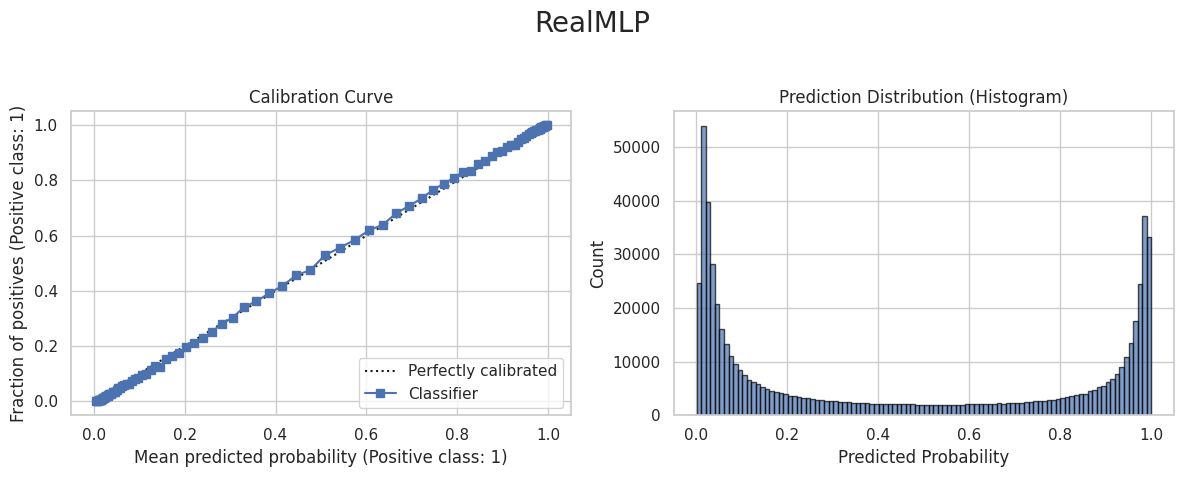

In [36]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(12, 5))
plt.suptitle('RealMLP', fontsize=20)

ax1 = plt.subplot(1, 2, 1)
CalibrationDisplay.from_predictions(y, oof_preds, n_bins=100, strategy='quantile', ax=ax1)
ax1.set_title('Calibration Curve')

ax2 = plt.subplot(1, 2, 2)
ax2.hist(oof_preds, bins=100, edgecolor='black', alpha=0.7)
ax2.set_title('Prediction Distribution (Histogram)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

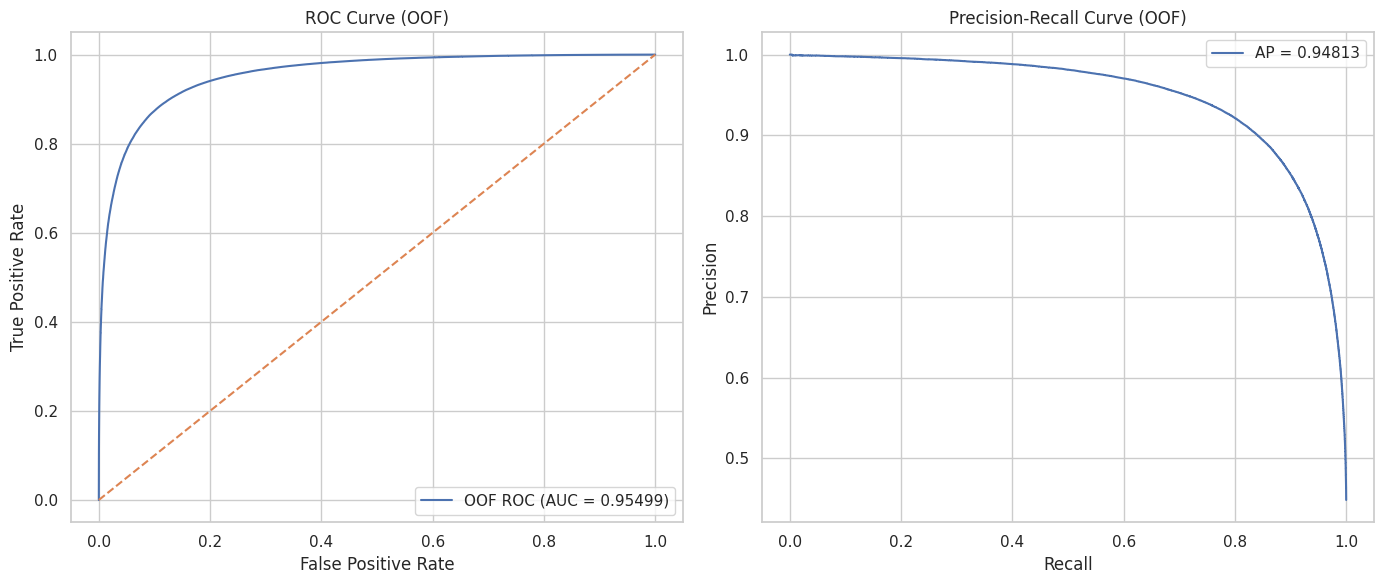

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Create figure with 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y, oof_preds)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, label=f'OOF ROC (AUC = {roc_auc:.5f})')
ax1.plot([0, 1], [0, 1], linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve (OOF)')
ax1.legend()
ax1.grid(True)

# ---- Precision-Recall Curve ----
precision, recall, _ = precision_recall_curve(y, oof_preds)
ap = average_precision_score(y, oof_preds)

ax2.plot(recall, precision, label=f'AP = {ap:.5f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve (OOF)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


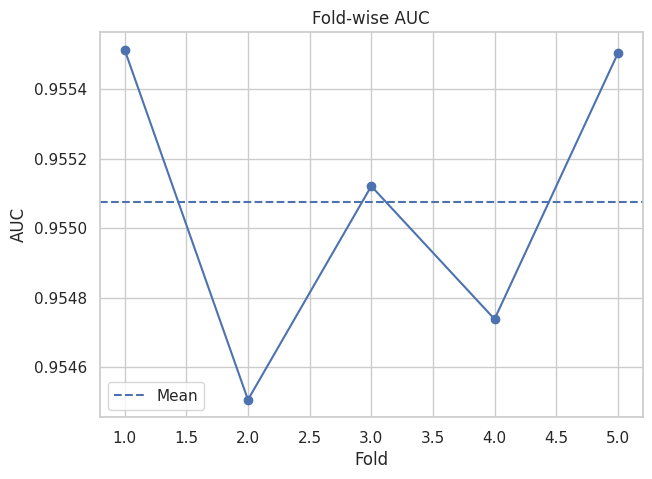

In [38]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, N_FOLDS+1), fold_scores, marker='o')
plt.axhline(np.mean(fold_scores), linestyle='--', label='Mean')

plt.xlabel('Fold')
plt.ylabel('AUC')
plt.title('Fold-wise AUC')
plt.legend()
plt.grid(True)
plt.show()


### Evaluation and Submission

In [39]:
total_oof_score = roc_auc_score(y, oof_preds)

print("\n" + "="*40)
print(f"Overall OOF ROC-AUC (avg OOF): {total_oof_score:.5f}")
print("="*40)

# Save OOF predictions for competition train rows only
comp_len = len(train_comp)
comp_oof = oof_preds[:comp_len]
comp_ids = train_comp['id'].values
pd.DataFrame({'id': comp_ids, 'Heart Disease_prob': comp_oof}).to_csv('oof_preds_train.csv', index=False)
print('OOF predictions saved to oof_preds_train.csv')



Overall OOF ROC-AUC (avg OOF): 0.95499
OOF predictions saved to oof_preds_train.csv


In [40]:
# Fold Scores Table
fold_df = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(fold_scores))],
    "ROC-AUC": fold_scores,
})
fold_df


,Fold,ROC-AUC
0,Fold 1,0.955514
1,Fold 2,0.954505
2,Fold 3,0.955121
3,Fold 4,0.954738
4,Fold 5,0.955503


In [30]:
submission = pd.DataFrame({'id': test['id'], 'Heart Disease': test_preds})
submission.to_csv('submission.csv', index=False)

print('Submission saved!')
print(f'Shape: {submission.shape}')

if len(submission) != 270000:
    raise ValueError(f"CRITICAL ERROR: Submission row count {len(submission)} != expected 270000")

submission.head()

Submission saved!
Shape: (270000, 2)


,id,Heart Disease
0,630000,0.951504
1,630001,0.008806
2,630002,0.989358
3,630003,0.005815
4,630004,0.176147
